# 07 - Modeling: Laptop Price Prediction

This notebook trains and evaluates regression models for laptop price prediction using the fully preprocessed dataset.

Main principles:
- Use one fixed 80/20 train/test split for both targets.
- Never include `price` or `logprice` in the feature matrix.
- Train each model twice: once on `price`, once on `logprice`.
- Convert `logprice` predictions back to the original price scale before the main comparison.
- Save clean artifacts for downstream analysis notebooks.

## 1. Import libraries

Cell này gom các thư viện cần thiết cho toàn bộ quy trình modeling: xử lý dữ liệu, chia tập train/test, huấn luyện mô hình, tính metric, trực quan hóa và lưu artifact. Các warning không quan trọng như `ConvergenceWarning` được ẩn để notebook gọn hơn, nhưng các lỗi train model thật sự vẫn được bắt và in rõ ràng ở phần training.

In [1]:
from __future__ import annotations

import importlib
import pickle
import time
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    max_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 2. Configuration

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Choose the inverse transformation used to convert log predictions back to price.
# Use 'log1p' if logprice = np.log1p(price), or 'log' if logprice = np.log(price).
LOG_TRANSFORM = 'log1p'
CLIP_NEGATIVE_PREDICTIONS = True

PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'laptop_processed_level.csv'

ARTIFACT_DIR = PROJECT_ROOT / 'artifacts' / 'modeling_level'
METRICS_DIR = ARTIFACT_DIR / 'metrics'
PREDICTIONS_DIR = ARTIFACT_DIR / 'predictions'
PLOTS_DIR = PROJECT_ROOT / "reports" / "figures" / "modeling_level"
MODELS_DIR = ARTIFACT_DIR / 'models'
FEATURE_IMPORTANCE_DIR = ARTIFACT_DIR / 'feature_importance'

for directory in [METRICS_DIR, PREDICTIONS_DIR, PLOTS_DIR, MODELS_DIR, FEATURE_IMPORTANCE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MODEL_NAME_FOR_FILE = {
    'Linear Regression': 'LinearRegression',
    'Ridge': 'Ridge',
    'Lasso': 'Lasso',
    'ElasticNet': 'ElasticNet',
    'Random Forest': 'RandomForest',
    'Extra Trees': 'ExtraTrees',
    'XGBoost': 'XGBoost',
    'LightGBM': 'LightGBM',
    'CatBoost': 'CatBoost',
}

print(f'Data path: {DATA_PATH}')
print(f'Artifacts path: {ARTIFACT_DIR}')

# ── Report artifact mirroring ─────────────────────────────────────────────────
# Keep the original artifact paths for downstream notebooks, and mirror every
# generated table/figure into reports/tables and reports/figures for the report.
NOTEBOOK_SLUG = "07a_modeling_level"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_FIGURES_DIR = REPORT_DIR / "figures" / NOTEBOOK_SLUG
REPORT_TABLES_DIR = REPORT_DIR / "tables" / NOTEBOOK_SLUG
for directory in [REPORT_FIGURES_DIR, REPORT_TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def _report_relative_path(path):
    path = Path(path)
    try:
        path = path.resolve()
    except OSError:
        path = path.absolute()
    for base in [PROJECT_ROOT / "artifacts", PROJECT_ROOT / "reports", PROJECT_ROOT]:
        try:
            return path.relative_to(base.resolve())
        except ValueError:
            continue
    return Path(path.name)


def _mirror_report_artifact(path, destination_root):
    if path is None or destination_root is None or not isinstance(path, (str, Path)):
        return
    src = Path(path)
    if not src.exists() or not src.is_file():
        return
    rel = _report_relative_path(src)
    dst = destination_root / rel
    try:
        if src.resolve() == dst.resolve():
            return
    except OSError:
        pass
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)


import shutil
from matplotlib.figure import Figure

if not hasattr(pd.DataFrame, "_reports_original_to_csv"):
    pd.DataFrame._reports_original_to_csv = pd.DataFrame.to_csv
if not hasattr(pd.Series, "_reports_original_to_csv"):
    pd.Series._reports_original_to_csv = pd.Series.to_csv
if not hasattr(pd.DataFrame, "_reports_original_to_excel"):
    pd.DataFrame._reports_original_to_excel = pd.DataFrame.to_excel
if not hasattr(Figure, "_reports_original_savefig"):
    Figure._reports_original_savefig = Figure.savefig


def _to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _series_to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.Series._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _to_excel_with_report_mirror(self, excel_writer, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_excel(self, excel_writer, *args, **kwargs)
    _mirror_report_artifact(excel_writer, globals().get("REPORT_TABLES_DIR"))
    return result


def _savefig_with_report_mirror(self, fname, *args, **kwargs):
    result = Figure._reports_original_savefig(self, fname, *args, **kwargs)
    _mirror_report_artifact(fname, globals().get("REPORT_FIGURES_DIR"))
    return result


_to_csv_with_report_mirror._reports_mirror_patch = True
_series_to_csv_with_report_mirror._reports_mirror_patch = True
_to_excel_with_report_mirror._reports_mirror_patch = True
_savefig_with_report_mirror._reports_mirror_patch = True
pd.DataFrame.to_csv = _to_csv_with_report_mirror
pd.Series.to_csv = _series_to_csv_with_report_mirror
pd.DataFrame.to_excel = _to_excel_with_report_mirror
Figure.savefig = _savefig_with_report_mirror

print(f"Report figures mirrored to: {REPORT_FIGURES_DIR}")
print(f"Report tables mirrored to : {REPORT_TABLES_DIR}")


Data path: Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_level.csv
Artifacts path: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_level
Report figures mirrored to: Y:\Python\Laptop-Price-Prediction\reports\figures\07a_modeling_level
Report tables mirrored to : Y:\Python\Laptop-Price-Prediction\reports\tables\07a_modeling_level


## 3. Load preprocessed data

Dữ liệu đầu vào được giả định là bản đã preprocessing hoàn chỉnh, vì vậy notebook không làm lại EDA hay feature engineering. Hàm `standardize_target_columns` chỉ chuẩn hóa tên target về `price` và `logprice`; với file hiện tại, hai cột gốc là `target_price` và `log_target_price`, nên bước này giúp notebook vừa đúng yêu cầu modeling vừa chạy được với schema thực tế.

In [3]:
df = pd.read_csv(DATA_PATH)

required_targets = {'target_price', 'log_target_price'}
missing_targets = required_targets.difference(df.columns)
if missing_targets:
    raise ValueError(f'Missing required target columns: {sorted(missing_targets)}')

print(f'Dataset shape: {df.shape}')
display(df.head())
display(df[['target_price', 'log_target_price']].describe())

Dataset shape: (7296, 88)


,brand_is_rare,model_is_rare,ram_missing,storage_missing,screen_missing,target_price,log_target_price,no_info_brand,no_info_model,no_info_cpu_brand,no_info_cpu_tier,no_info_gpu,ram_level,storage_level,screen_size_level,storage_ssd,storage_hdd,no_info_storage,condition_score,warranty_encoded,cpu_tier_encoded,brand_ASUS,brand_Acer,brand_Apple,brand_Dell,brand_Gigabyte,brand_HP,brand_LG,brand_Lenovo,brand_MSI,brand_Microsoft,brand_Other,brand_Sony,brand_Toshiba,model_Aspire,model_Elitebook,model_Elitebook 800,model_Gaming Thin GF,model_IdeaPad,model_Inspiron,model_Latitude,model_Latitude 14 7000,model_Latitude E Series,model_Legion,model_Legion 5,model_MacBook Air,model_MacBook Air M1,model_MacBook Air M2,model_MacBook Pro,model_MacBook Pro M1,model_MacBook Pro M2,model_Macbook air m4,model_Nitro 5,model_Other,model_Pavilion 15,model_Precision,model_ProBook,model_ROG Strix,model_TUF Gaming,model_TUF Gaming F15,model_ThinkPad,model_ThinkPad X1 Carbon,model_Vivobook 15,model_Vostro,model_X Series,model_XPS 13,cpu_brand_AMD,cpu_brand_Apple,cpu_brand_Intel,cpu_brand_Microsoft SQ,cpu_brand_Other,cpu_brand_Qualcomm,cpu_family_ord_filled,cpu_family_group_AMD Ryzen,cpu_family_group_Apple Silicon,cpu_family_group_Intel Core Ultra,cpu_family_group_Intel Core i,cpu_family_group_Intel Low End,cpu_intel_generation_ord,cpu_amd_generation_ord,cpu_apple_core_spec,cpu_qualcomm_snapdragon_spec,cpu_suffix_power_ord_filled,gpu_tier_ord_filled,gpu_type_Apple SoC,gpu_type_Dedicated,gpu_type_Integrated,gpu_type_Missing_Info
0,0,0,0,0,0,9.9900,2.3970,0,0,0,0,0,4,2,1,1,0,0,2,1,6,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,4.5000,1.7047,0,1,0,0,0,3,1,3,1,0,0,2,1,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,3.5000,1.5041,0,1,0,0,0,3,3,1,1,0,0,2,1,6,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,37.5000,3.6507,0,1,0,1,0,5,3,1,1,0,0,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,7.9900,2.1961,0,1,1,1,0,4,2,1,1,0,0,2,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


,target_price,log_target_price
count,"7,296.0000","7,296.0000"
mean,14.9491,2.4476
std,15.3312,0.7893
min,1.0000,0.6931
25%,5.6000,1.8871
50%,10.5000,2.4423
75%,18.8125,2.9863
max,179.4000,5.1952


## 4. Define feature matrix and targets

Đây là bước quan trọng nhất để tránh data leakage. Feature matrix `X` được tạo bằng cách loại bỏ cả `price` và `logprice`, còn hai target được giữ riêng biệt: `y_price` dùng cho mô hình dự đoán giá trực tiếp, `y_logprice` dùng cho mô hình học trên log scale. Notebook cũng kiểm tra lại rằng không còn target nào nằm trong `X` trước khi train.

In [4]:
TARGET_COLUMNS = ['target_price', 'log_target_price']

X = df.drop(columns=TARGET_COLUMNS)
y_price = df['target_price']
y_logprice = df['log_target_price']

leakage_columns = {'target_price', 'log_target_price'}.intersection(X.columns)
if leakage_columns:
    raise ValueError(f'Data leakage detected in X: {sorted(leakage_columns)}')

non_numeric_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_columns:
    raise ValueError(
        'All features should be numeric after preprocessing. '
        f'Non-numeric columns found: {non_numeric_columns}'
    )

feature_names = X.columns.tolist()

print(f'Feature matrix shape: {X.shape}')
print(f'Price target shape: {y_price.shape}')
print(f'Logprice target shape: {y_logprice.shape}')

Feature matrix shape: (7296, 86)
Price target shape: (7296,)
Logprice target shape: (7296,)


## 5. Train/test split 80/20

Cùng một lệnh `train_test_split` được dùng đồng thời cho `X`, `y_price` và `y_logprice`. Cách này đảm bảo mọi model, dù train trên target nào, đều được so sánh trên đúng cùng tập test và cùng các sample, giúp kết quả giữa `price` và `logprice` công bằng hơn.

In [5]:
X_train, X_test, y_price_train, y_price_test, y_log_train, y_log_test = train_test_split(
    X,
    y_price,
    y_logprice,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'y_price_train: {y_price_train.shape}')
print(f'y_log_train  : {y_log_train.shape}')
print('Same split is used for price and logprice targets.')

X_train: (5836, 86)
X_test : (1460, 86)
y_price_train: (5836,)
y_log_train  : (5836,)
Same split is used for price and logprice targets.


## 6. Define metrics functions

Các metric chính gồm MAE, RMSE, R2, MAPE, Median Absolute Error và Max Error. Với bảng so sánh chính, tất cả metric luôn được tính trên cùng đơn vị là giá laptop thật (`price scale`), vì đây là đơn vị có ý nghĩa trực tiếp nhất khi báo cáo sai số dự đoán.

In [6]:
def calculate_metrics(y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Calculate regression metrics on the same scale for y_true and y_pred."""
    y_true_arr = np.asarray(y_true, dtype=float)
    y_pred_arr = np.asarray(y_pred, dtype=float)

    return {
        'mae': mean_absolute_error(y_true_arr, y_pred_arr),
        'rmse': root_mean_squared_error(y_true_arr, y_pred_arr),
        'r2': r2_score(y_true_arr, y_pred_arr),
        'mape': mean_absolute_percentage_error(y_true_arr, y_pred_arr),
        'median_ae': median_absolute_error(y_true_arr, y_pred_arr),
        'max_error': max_error(y_true_arr, y_pred_arr),
    }

## 7. Define inverse log transform function

Mô hình train bằng `logprice` sẽ predict ra giá trị trên log scale. Trước khi so sánh với `y_price_test`, prediction này bắt buộc được inverse về price scale bằng `np.expm1` hoặc `np.exp` tùy cấu hình. Notebook cũng clip prediction âm về 0 để tránh các giá trị không hợp lý sau inverse transform.

In [7]:
def inverse_log_transform(y_pred_log: np.ndarray, method: str = 'log1p') -> np.ndarray:
    """Convert log-scale predictions back to price scale."""
    y_pred_log = np.asarray(y_pred_log, dtype=float)

    if method == 'log1p':
        y_pred_price = np.expm1(y_pred_log)
    elif method == 'log':
        y_pred_price = np.exp(y_pred_log)
    else:
        raise ValueError("method must be either 'log1p' or 'log'")

    if CLIP_NEGATIVE_PREDICTIONS:
        y_pred_price = np.maximum(y_pred_price, 0)

    return y_pred_price


def infer_log_transform(y_price_values: pd.Series, y_log_values: pd.Series) -> pd.DataFrame:
    """Quick diagnostic comparing configured transform to observed target values."""
    price = np.asarray(y_price_values, dtype=float)
    log_values = np.asarray(y_log_values, dtype=float)
    diagnostics = pd.DataFrame(
        {
            'method': ['log1p', 'log'],
            'mean_abs_difference': [
                np.mean(np.abs(np.log1p(price) - log_values)),
                np.mean(np.abs(np.log(price) - log_values)),
            ],
        }
    ).sort_values('mean_abs_difference')
    return diagnostics

log_transform_diagnostics = infer_log_transform(y_price, y_logprice)
display(log_transform_diagnostics)
print(f'Configured LOG_TRANSFORM = {LOG_TRANSFORM!r}')

,method,mean_abs_difference
0,log1p,0.0000
1,log,0.1297


Configured LOG_TRANSFORM = 'log1p'


## 8. Define models

Danh sách model được định nghĩa theo một cấu trúc thống nhất gồm tên model, loại model và estimator. Các model tuyến tính được đặt trong pipeline có `StandardScaler` vì chúng nhạy với thang đo feature; các tree-based model không cần scaler. XGBoost, LightGBM và CatBoost là optional: nếu môi trường chưa cài, notebook chỉ cảnh báo và bỏ qua thay vì dừng toàn bộ quy trình.

In [8]:
def optional_import(module_name: str, class_name: str) -> Optional[Any]:
    """Import optional model classes without crashing the notebook."""
    try:
        module = importlib.import_module(module_name)
        return getattr(module, class_name)
    except Exception as exc:
        print(f'Warning: {class_name} is not available and will be skipped. Details: {exc}')
        return None


def make_linear_pipeline(estimator: Any) -> Pipeline:
    return Pipeline(
        steps=[
            ('scaler', StandardScaler()),
            ('model', estimator),
        ]
    )


def define_models() -> List[Dict[str, Any]]:
    models: List[Dict[str, Any]] = [
        {
            'model_name': 'Linear Regression',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(LinearRegression()),
        },
        {
            'model_name': 'Ridge',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(Ridge(alpha=1.0)),
        },
        {
            'model_name': 'Lasso',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(Lasso(alpha=0.001, max_iter=10000)),
        },
        {
            'model_name': 'ElasticNet',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)),
        },
        {
            'model_name': 'Random Forest',
            'model_type': 'tree_ensemble',
            'estimator': RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        },
        {
            'model_name': 'Extra Trees',
            'model_type': 'tree_ensemble',
            'estimator': ExtraTreesRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        },
    ]

    XGBRegressor = optional_import('xgboost', 'XGBRegressor')
    if XGBRegressor is not None:
        models.append(
            {
                'model_name': 'XGBoost',
                'model_type': 'gradient_boosting',
                'estimator': XGBRegressor(
                    n_estimators=500,
                    learning_rate=0.05,
                    max_depth=6,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=RANDOM_STATE,
                    objective='reg:squarederror',
                    n_jobs=-1,
                ),
            }
        )

    LGBMRegressor = optional_import('lightgbm', 'LGBMRegressor')
    if LGBMRegressor is not None:
        models.append(
            {
                'model_name': 'LightGBM',
                'model_type': 'gradient_boosting',
                'estimator': LGBMRegressor(
                    n_estimators=500,
                    learning_rate=0.05,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            }
        )

    CatBoostRegressor = optional_import('catboost', 'CatBoostRegressor')
    if CatBoostRegressor is not None:
        models.append(
            {
                'model_name': 'CatBoost',
                'model_type': 'gradient_boosting',
                'estimator': CatBoostRegressor(
                    iterations=500,
                    learning_rate=0.05,
                    depth=6,
                    random_seed=RANDOM_STATE,
                    verbose=0,
                    allow_writing_files=False,
                ),
            }
        )

    return models


model_specs = define_models()
print(f'Number of models to train: {len(model_specs)}')
print([spec['model_name'] for spec in model_specs])

Number of models to train: 8
['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'Random Forest', 'Extra Trees', 'LightGBM', 'CatBoost']


## Helper functions for training, persistence, plots, and feature importance

Các hàm helper giúp notebook ngắn gọn và dễ bảo trì hơn. Một hàm training duy nhất được dùng cho cả hai target, trong đó logic khác biệt nằm ở bước hậu xử lý prediction: target `price` được dùng trực tiếp, còn target `logprice` được inverse về price scale trước khi tính metric và lưu prediction.

In [9]:
def safe_filename(model_name: str, target_used: str) -> str:
    base_name = MODEL_NAME_FOR_FILE.get(model_name, model_name.replace(' ', ''))
    return f'{base_name}_{target_used}'


def save_model(model: Any, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, path)


def train_and_evaluate_model(
    model: Any,
    model_name: str,
    model_type: str,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test_price: pd.Series,
    target_used: str,
    y_test_log: Optional[pd.Series] = None,
) -> Tuple[Any, Dict[str, Any], np.ndarray, Optional[Dict[str, float]]]:
    """Fit a model and evaluate predictions on price scale."""
    estimator = clone(model)

    start_train = time.perf_counter()
    estimator.fit(X_train, y_train)
    train_time_sec = time.perf_counter() - start_train

    start_pred = time.perf_counter()
    raw_pred = estimator.predict(X_test)
    predict_time_sec = time.perf_counter() - start_pred

    log_scale_metrics = None
    if target_used == 'log_target_price':
        y_pred_price = inverse_log_transform(raw_pred, method=LOG_TRANSFORM)
        if y_test_log is not None:
            log_scale_metrics = calculate_metrics(y_test_log, raw_pred)
    elif target_used == 'target_price':
        y_pred_price = np.asarray(raw_pred, dtype=float)
        if CLIP_NEGATIVE_PREDICTIONS:
            y_pred_price = np.maximum(y_pred_price, 0)
    else:
        raise ValueError("target_used must be 'target_price' or 'log_target_price'")

    metrics = calculate_metrics(y_test_price, y_pred_price)
    metrics.update(
        {
            'model_name': model_name,
            'model_type': model_type,
            'target_used': target_used,
            'evaluation_scale': 'target_price',
            'train_time_sec': train_time_sec,
            'predict_time_sec': predict_time_sec,
        }
    )

    return estimator, metrics, y_pred_price, log_scale_metrics


def plot_metric_comparison(metrics_df: pd.DataFrame, metric_name: str) -> None:
    metric_label = metric_name.upper() if metric_name in ['mae', 'rmse', 'r2', 'mape'] else metric_name
    plot_df = metrics_df.sort_values(metric_name, ascending=(metric_name != 'r2'))

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=plot_df, x='model_name', y=metric_name, hue='target_used')
    ax.set_title(f'{metric_label} Comparison by Model and Target')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric_label)
    ax.tick_params(axis='x', rotation=35)
    plt.legend(title='Target used')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'{metric_name}_comparison.png', dpi=160, bbox_inches='tight')
    plt.show()


def plot_actual_vs_predicted(y_true: pd.Series, y_pred: np.ndarray, model_name: str, target_used: str) -> None:
    plt.figure(figsize=(7, 7))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.55, edgecolor=None)
    min_value = min(np.min(y_true), np.min(y_pred))
    max_value = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_value, max_value], [min_value, max_value], color='red', linestyle='--', linewidth=1.5)
    plt.title(f'Actual vs Predicted - {model_name} ({target_used})')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'actual_vs_predicted_{safe_filename(model_name, target_used)}.png', dpi=160, bbox_inches='tight')
    plt.show()


def plot_residuals(
    y_true: pd.Series,
    y_pred: np.ndarray,
    model_name: str,
    target_used: str,
    ax=None,
    save: bool = True
) -> None:
    residuals = np.asarray(y_true) - np.asarray(y_pred)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        show_plot = True
    else:
        fig = ax.figure
        show_plot = False

    sns.scatterplot(
        x=y_pred,
        y=residuals,
        alpha=0.55,
        edgecolor=None,
        ax=ax
    )

    ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"Residual Plot - {model_name} ({target_used})")
    ax.set_xlabel("Predicted Price")
    ax.set_ylabel("Residual: Actual - Predicted")

    if show_plot:
        fig.tight_layout()

        if save:
            fig.savefig(
                PLOTS_DIR / f"residuals_{safe_filename(model_name, target_used)}.png",
                dpi=160,
                bbox_inches="tight"
            )

        plt.show()


def plot_error_distribution(
    y_true: pd.Series,
    y_pred: np.ndarray,
    model_name: str,
    target_used: str,
    ax=None,
    save: bool = True
) -> None:
    errors = np.asarray(y_true) - np.asarray(y_pred)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        show_plot = True
    else:
        fig = ax.figure
        show_plot = False

    sns.histplot(
        errors,
        kde=True,
        bins=40,
        ax=ax
    )

    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"Error Distribution - {model_name} ({target_used})")
    ax.set_xlabel("Prediction Error: Actual - Predicted")
    ax.set_ylabel("Count")

    if show_plot:
        fig.tight_layout()

        if save:
            fig.savefig(
                PLOTS_DIR / f"error_distribution_{safe_filename(model_name, target_used)}.png",
                dpi=160,
                bbox_inches="tight"
            )

        plt.show()

def plot_target_comparison(metrics_df: pd.DataFrame, metric_name: str = 'rmse') -> None:
    comparison_df = metrics_df.pivot(index='model_name', columns='target_used', values=metric_name)
    comparison_df = comparison_df.dropna(how='all').sort_values(by=comparison_df.columns.tolist())

    ax = comparison_df.plot(kind='bar', figsize=(12, 6), width=0.8)
    metric_label = metric_name.upper() if metric_name in ['mae', 'rmse', 'r2', 'mape'] else metric_name
    ax.set_title(f'Price Target vs Logprice Target by Model ({metric_label})')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric_label)
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Target used')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'target_comparison_{metric_name}.png', dpi=160, bbox_inches='tight')
    plt.show()


def _get_estimator_for_importance(model: Any) -> Any:
    if isinstance(model, Pipeline):
        return model.named_steps.get('model')
    return model


def extract_feature_importance(model: Any, model_name: str, feature_names: List[str]) -> Optional[pd.DataFrame]:
    """Extract feature importances or coefficients when available."""
    fitted_model = _get_estimator_for_importance(model)

    if hasattr(fitted_model, 'feature_importances_'):
        importance = fitted_model.feature_importances_
        importance_type = 'feature_importance'
    elif hasattr(fitted_model, 'coef_'):
        importance = np.ravel(fitted_model.coef_)
        importance_type = 'coefficient'
    else:
        return None

    importance_df = pd.DataFrame(
        {
            'feature': feature_names,
            'importance': importance,
            'abs_importance': np.abs(importance),
            'model_name': model_name,
            'importance_type': importance_type,
        }
    ).sort_values('abs_importance', ascending=False)

    return importance_df

## 9. Train models on `price` and 10. Train models on `logprice`

Vòng lặp training chạy mỗi model hai lần: một lần với target `price`, một lần với target `logprice`. Sau mỗi lần train, notebook lưu model `.pkl`, lưu prediction trên test set, ghi metric chính trên price scale và nếu là log model thì lưu thêm metric phụ trên log scale để tham khảo.

In [10]:
trained_models: Dict[str, Any] = {}
metrics_records: List[Dict[str, Any]] = []
log_scale_metric_records: List[Dict[str, Any]] = []
predictions_df = pd.DataFrame(
    {
        'sample_id': X_test.index,
        'y_true_price': y_price_test.values,
    },
    index=X_test.index,
)

for spec in model_specs:
    model_name = spec['model_name']
    model_type = spec['model_type']
    estimator = spec['estimator']

    for target_used, y_train_current in [('target_price', y_price_train), ('log_target_price', y_log_train)]:
        print(f'Training {model_name} on {target_used}...')
        try:
            fitted_model, metrics, y_pred_price, log_metrics = train_and_evaluate_model(
                model=estimator,
                model_name=model_name,
                model_type=model_type,
                X_train=X_train,
                X_test=X_test,
                y_train=y_train_current,
                y_test_price=y_price_test,
                target_used=target_used,
                y_test_log=y_log_test,
            )
        except Exception as exc:
            print(f'Warning: {model_name} ({target_used}) failed and will be skipped. Details: {exc}')
            continue

        key = f'{model_name}_{target_used}'
        trained_models[key] = fitted_model
        metrics_records.append(metrics)
        predictions_df[f'pred_{safe_filename(model_name, target_used)}'] = y_pred_price

        if log_metrics is not None:
            log_metrics.update(
                {
                    'model_name': model_name,
                    'model_type': model_type,
                    'target_used': target_used,
                    'evaluation_scale': 'log_target_price',
                }
            )
            log_scale_metric_records.append(log_metrics)

        model_path = MODELS_DIR / f'{safe_filename(model_name, target_used)}.pkl'
        save_model(fitted_model, model_path)

print(f'Trained model variants: {len(trained_models)}')

Training Linear Regression on target_price...
Training Linear Regression on log_target_price...
Training Ridge on target_price...
Training Ridge on log_target_price...
Training Lasso on target_price...
Training Lasso on log_target_price...
Training ElasticNet on target_price...
Training ElasticNet on log_target_price...
Training Random Forest on target_price...
Training Random Forest on log_target_price...
Training Extra Trees on target_price...
Training Extra Trees on log_target_price...
Training LightGBM on target_price...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001972 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 220
[LightGBM] [Info] Number of data points in the train set: 5836, number of used features: 81
[LightGBM] [Info] Start training from 

## 11. Evaluate all models on price scale

Bảng `metrics_df` là bảng so sánh chính của notebook. Dù model được train bằng target nào, các cột `mae`, `rmse`, `r2`, `mape`, `median_ae` và `max_error` đều phản ánh hiệu năng trên price scale. Vì vậy có thể đọc trực tiếp bảng này để chọn model phục vụ bài toán dự đoán giá.

In [11]:
metrics_df = pd.DataFrame(metrics_records)
metric_columns = [
    'model_name',
    'model_type',
    'target_used',
    'evaluation_scale',
    'mae',
    'rmse',
    'r2',
    'mape',
    'median_ae',
    'max_error',
    'train_time_sec',
    'predict_time_sec',
]
metrics_df = metrics_df[metric_columns].sort_values('rmse').reset_index(drop=True)

display(metrics_df)

if log_scale_metric_records:
    log_metrics_df = pd.DataFrame(log_scale_metric_records)
    display(log_metrics_df.sort_values('rmse').reset_index(drop=True))
else:
    log_metrics_df = pd.DataFrame()

,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,CatBoost,gradient_boosting,target_price,target_price,3.3709,5.4827,0.8870,0.3001,2.0150,36.6205,2.7868,0.0073
1,LightGBM,gradient_boosting,target_price,target_price,3.2904,5.4981,0.8864,0.2817,1.8933,39.6096,2.3375,0.0160
2,LightGBM,gradient_boosting,log_target_price,target_price,3.2535,5.5300,0.8850,0.2627,1.8255,40.9106,2.6372,0.0149
3,Random Forest,tree_ensemble,target_price,target_price,3.4085,5.6870,0.8784,0.3021,1.9347,46.8513,2.7782,0.1352
4,CatBoost,gradient_boosting,log_target_price,target_price,3.3370,5.7407,0.8761,0.2621,1.8086,43.0101,2.1606,0.0040
5,Random Forest,tree_ensemble,log_target_price,target_price,3.4134,5.8456,0.8715,0.2830,1.8778,49.3828,2.4520,0.1441
6,Extra Trees,tree_ensemble,target_price,target_price,3.5442,5.9386,0.8674,0.3095,2.0429,61.2973,2.7481,0.1453
7,Extra Trees,tree_ensemble,log_target_price,target_price,3.5166,6.0317,0.8632,0.2936,1.9810,62.7549,2.7023,0.1672
8,Linear Regression,linear,log_target_price,target_price,4.0736,6.9260,0.8197,0.3191,2.1951,48.6459,1.0183,0.0226
9,Lasso,linear,log_target_price,target_price,4.0807,6.9425,0.8188,0.3196,2.1852,50.2717,1.2141,0.0133


,mae,rmse,r2,mape,median_ae,max_error,model_name,model_type,target_used,evaluation_scale
0,0.2193,0.2900,0.8644,0.1050,0.1725,2.0720,CatBoost,gradient_boosting,log_target_price,log_target_price
1,0.2187,0.2919,0.8626,0.1058,0.1763,2.1014,LightGBM,gradient_boosting,log_target_price,log_target_price
2,0.2312,0.3094,0.8456,0.1123,0.1773,1.8155,Random Forest,tree_ensemble,log_target_price,log_target_price
3,0.2401,0.3229,0.8318,0.1163,0.1782,1.7922,Extra Trees,tree_ensemble,log_target_price,log_target_price
4,0.2618,0.3357,0.8182,0.1253,0.2120,1.8717,Linear Regression,linear,log_target_price,log_target_price
5,0.2621,0.3361,0.8178,0.1253,0.2119,1.8786,Ridge,linear,log_target_price,log_target_price
6,0.2620,0.3362,0.8177,0.1254,0.2132,1.8796,ElasticNet,linear,log_target_price,log_target_price
7,0.2621,0.3363,0.8177,0.1255,0.2118,1.8805,Lasso,linear,log_target_price,log_target_price


### Nhận xét mô hình trên thang đo `log_target_price`

Bảng kết quả cho thấy nhóm mô hình boosting vẫn cho hiệu năng tốt nhất khi đánh giá trực tiếp trên thang đo `log_target_price`. Trong đó, `CatBoost` đạt kết quả cao nhất với MAE = 0.2193, RMSE = 0.2900 và R² = 0.8644. `LightGBM` đứng rất sát phía sau với MAE = 0.2187, RMSE = 0.2919 và R² = 0.8626.

Khoảng cách giữa `CatBoost` và `LightGBM` là rất nhỏ. `LightGBM` có MAE thấp hơn nhẹ, nhưng `CatBoost` tốt hơn ở RMSE, R², median absolute error và max error. Vì vậy, nếu ưu tiên độ ổn định tổng thể và khả năng kiểm soát lỗi lớn, `CatBoost` vẫn là lựa chọn tốt hơn.

Các mô hình tree ensemble như `Random Forest` và `Extra Trees` có hiệu năng thấp hơn nhóm boosting, với R² lần lượt khoảng 0.846 và 0.832. Điều này cho thấy boosting học tốt hơn các quan hệ phi tuyến và interaction giữa các đặc trưng trong bài toán dự đoán giá laptop.

Nhóm linear models có kết quả thấp nhất, với R² chỉ khoảng 0.818. Dù vậy, hiệu năng của nhóm này không quá kém trên log scale, cho thấy log-transform đã giúp bài toán trở nên tuyến tính hơn một phần. Tuy nhiên, linear models vẫn chưa đủ tốt để chọn làm mô hình chính.

Tóm lại, trên thang đo `log_target_price`, `CatBoost` là mô hình tốt nhất tổng thể, `LightGBM` là ứng viên rất cạnh tranh, còn nhóm linear models chỉ nên giữ vai trò baseline để so sánh.

## 12. Save metrics

Metrics được lưu thành CSV để các notebook phân tích tiếp theo có thể đọc lại mà không cần train lại model. File `model_metrics.csv` là artifact chính; file `log_scale_model_metrics.csv` chỉ là metric phụ cho nhóm model train bằng `logprice`.

In [12]:
metrics_path = METRICS_DIR / 'model_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f'Saved main metrics to: {metrics_path}')

if not log_metrics_df.empty:
    log_metrics_path = METRICS_DIR / 'log_scale_model_metrics.csv'
    log_metrics_df.to_csv(log_metrics_path, index=False)
    print(f'Saved optional log-scale metrics to: {log_metrics_path}')

Saved main metrics to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_level\metrics\model_metrics.csv
Saved optional log-scale metrics to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_level\metrics\log_scale_model_metrics.csv


## 13. Save predictions

File prediction giữ `sample_id`, giá thật và prediction của từng biến thể model. Cấu trúc wide-format này tiện cho các phân tích sau như residual analysis, so sánh từng sample, tìm nhóm laptop có sai số lớn, hoặc tạo ensemble từ nhiều model.

In [13]:
predictions_path = PREDICTIONS_DIR / 'test_predictions.csv'
predictions_df.reset_index(drop=True).to_csv(predictions_path, index=False)
print(f'Saved test predictions to: {predictions_path}')
display(predictions_df.head())

Saved test predictions to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_level\predictions\test_predictions.csv


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
3909,3909,5.5000,5.1244,5.0892,4.9042,5.1009,4.9049,5.0783,4.8954,5.0911,4.7560,4.3869,4.9560,5.7828,3.4152,3.6168,4.2923,3.7477
6004,6004,37.4990,23.7416,20.8051,23.8598,20.7210,23.8524,20.3518,23.8449,20.4887,30.5577,29.9456,32.1394,32.5956,28.1858,31.3315,27.8331,27.6703
1768,1768,27.4900,16.2240,13.5360,16.3601,13.5744,16.3640,13.4881,16.3678,13.4970,21.3259,19.5354,21.2413,19.3984,19.2228,18.4243,17.2601,16.3994
3360,3360,7.8000,7.5580,6.5008,7.2300,6.4839,7.2376,6.5164,7.2294,6.4988,8.6322,8.1455,10.0000,10.0000,7.6635,7.5268,7.8962,7.2573
4700,4700,12.9900,11.4057,9.5623,11.5210,9.5485,11.5308,9.7188,11.5252,9.6514,11.3804,11.4089,11.6000,11.5964,10.9634,11.0045,10.6491,10.5746


## 14. Save trained models

Mỗi model đã train được lưu riêng theo tên rõ ràng gồm model name và target đã dùng. Điều này giúp load lại đúng biến thể model khi cần inference hoặc phân tích feature importance mà không phải chạy lại notebook.

In [14]:
model_files = sorted(MODELS_DIR.glob('*.pkl'))
print(f'Saved {len(model_files)} model files to: {MODELS_DIR}')
for path in model_files:
    print(path.name)

Saved 16 model files to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_level\models
CatBoost_log_target_price.pkl
CatBoost_target_price.pkl
ElasticNet_log_target_price.pkl
ElasticNet_target_price.pkl
ExtraTrees_log_target_price.pkl
ExtraTrees_target_price.pkl
Lasso_log_target_price.pkl
Lasso_target_price.pkl
LightGBM_log_target_price.pkl
LightGBM_target_price.pkl
LinearRegression_log_target_price.pkl
LinearRegression_target_price.pkl
RandomForest_log_target_price.pkl
RandomForest_target_price.pkl
Ridge_log_target_price.pkl
Ridge_target_price.pkl


## 15. Generate comparison plots

Các biểu đồ so sánh MAE, RMSE và R2 giúp nhìn nhanh trade-off giữa model và target. Biểu đồ so sánh `price` vs `logprice` theo từng model đặc biệt hữu ích để trả lời câu hỏi: cùng một thuật toán, học trên target nào tốt hơn khi đánh giá trên đơn vị giá thật?

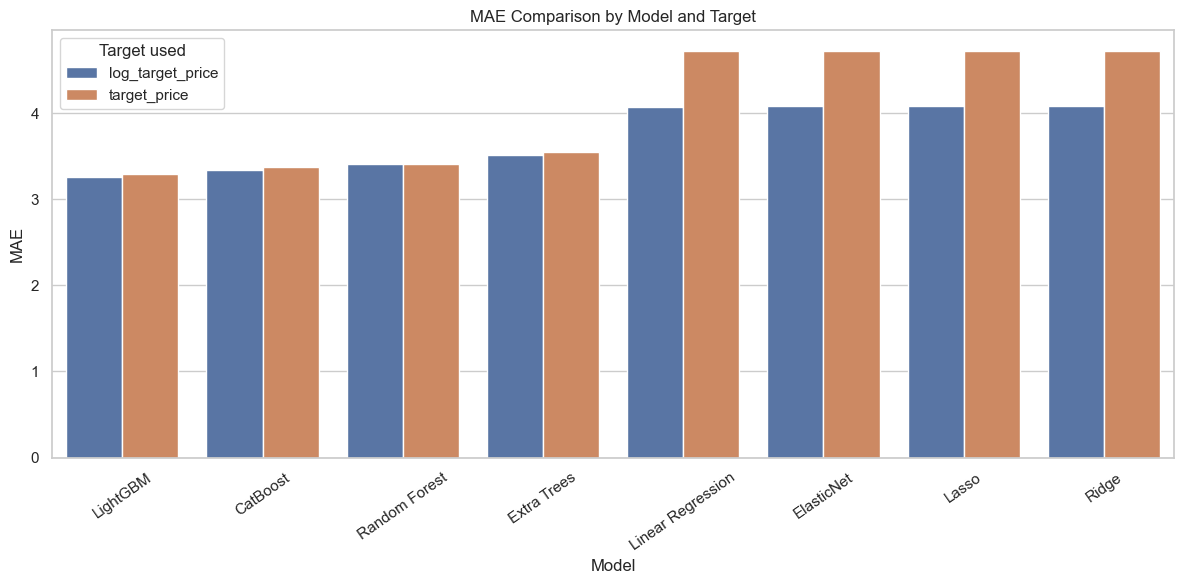

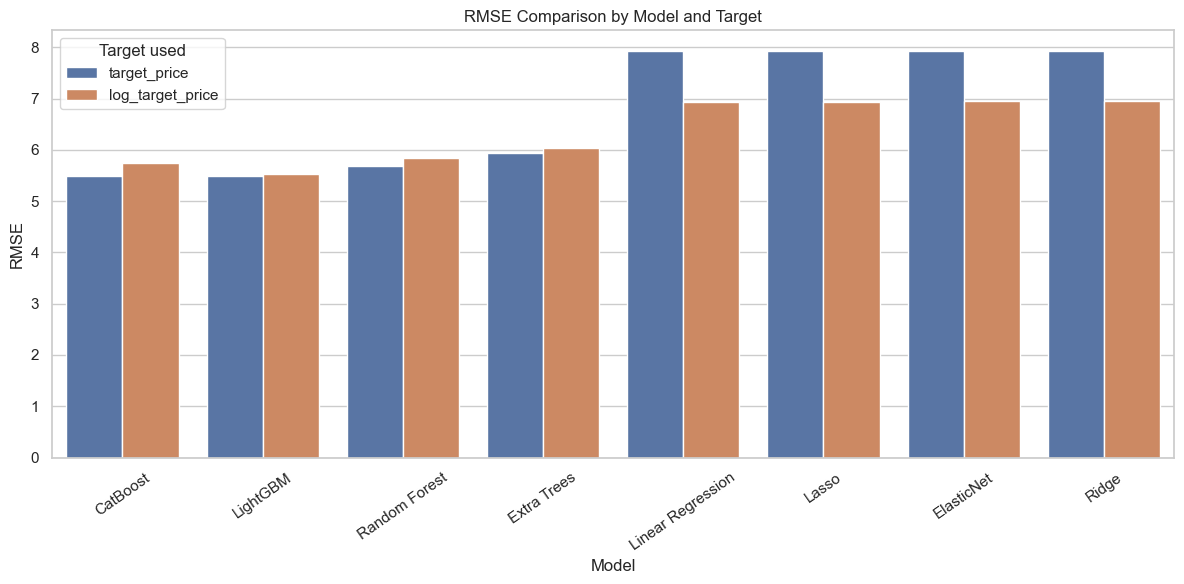

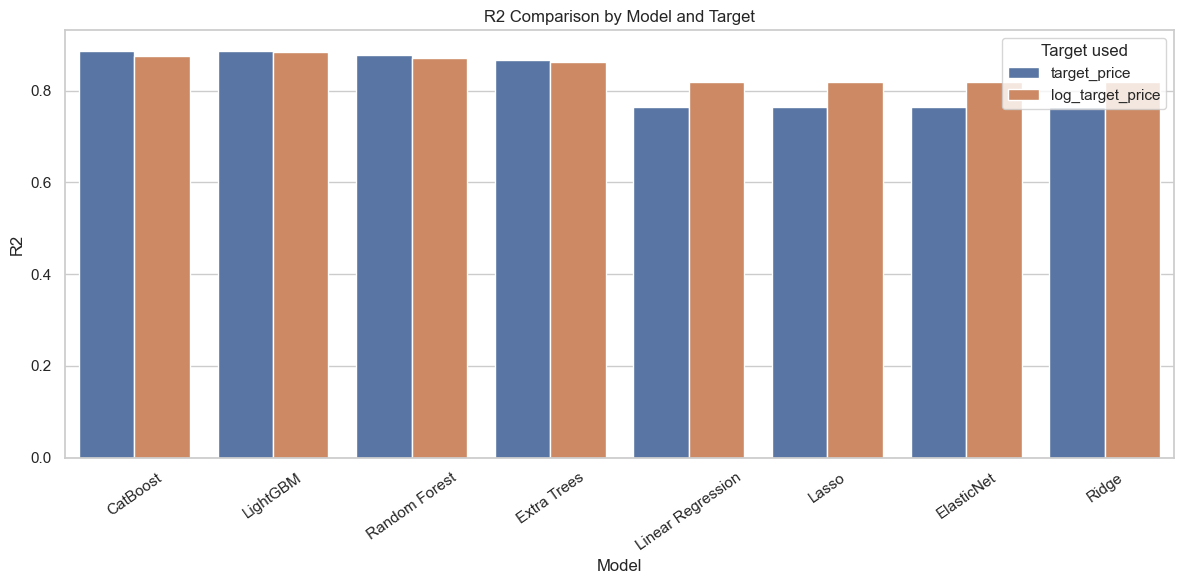

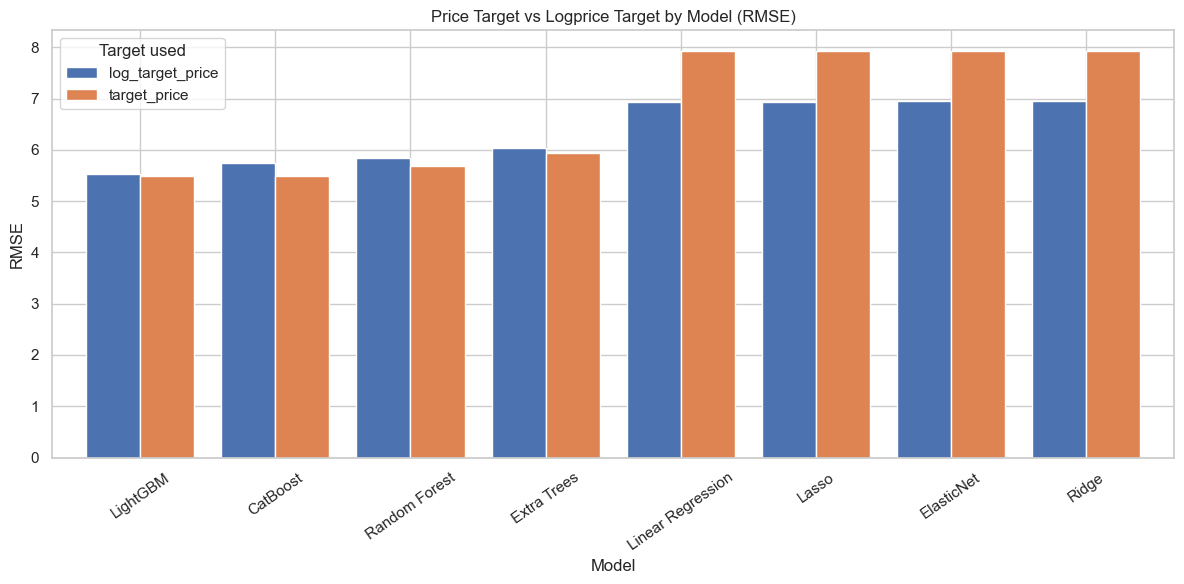

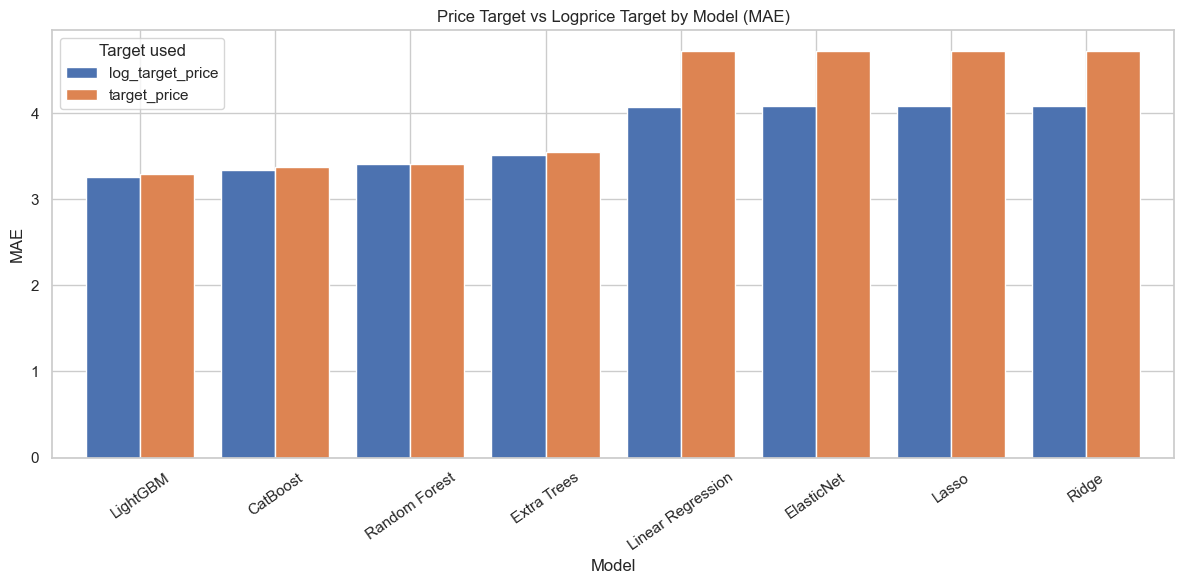

In [15]:
for metric in ['mae', 'rmse', 'r2']:
    plot_metric_comparison(metrics_df, metric)

plot_target_comparison(metrics_df, metric_name='rmse')
plot_target_comparison(metrics_df, metric_name='mae')

## Target Strategy Comparison

Các biểu đồ trên so sánh hiệu năng của từng mô hình khi train trực tiếp trên `target_price` và khi train trên `log_target_price`. Với các mô hình dùng `log_target_price`, giá trị dự đoán đã được inverse-transform về lại thang giá thật trước khi tính MAE, RMSE và R². Vì vậy, các chỉ số trong các biểu đồ này đều có thể so sánh trực tiếp trên cùng đơn vị là triệu VND.

Nhìn chung, nhóm mô hình tree-based ensemble cho kết quả tốt hơn nhóm linear models. `CatBoost` và `LightGBM` là hai mô hình có hiệu năng tốt nhất, thể hiện qua MAE và RMSE thấp, đồng thời R² cao. Điều này cho thấy các mô hình gradient boosting phù hợp hơn với bài toán dự đoán giá laptop, vì chúng có khả năng học các quan hệ phi tuyến và interaction giữa nhiều đặc trưng như CPU, GPU, RAM, storage, condition, warranty và brand.

### MAE Comparison

Biểu đồ MAE cho thấy `log_target_price` thường giúp giảm sai số trung bình tuyệt đối ở hầu hết các mô hình. Sự cải thiện rõ nhất nằm ở nhóm linear models như `Linear Regression`, `Ridge`, `Lasso` và `ElasticNet`. Khi train trực tiếp trên `target_price`, nhóm này có MAE khá cao, trong khi khi dùng `log_target_price`, MAE giảm đáng kể.

Ở nhóm tree-based models, sự khác biệt giữa hai target nhỏ hơn. `LightGBM`, `CatBoost`, `Random Forest` và `Extra Trees` có MAE khá gần nhau giữa hai cách train. Tuy nhiên, `log_target_price` vẫn thường nhỉnh hơn nhẹ hoặc ít nhất không làm hiệu năng xấu đi đáng kể. Điều này cho thấy log-transform giúp mô hình ổn định hơn về sai số trung bình, đặc biệt khi phân phối giá bị lệch phải và có nhiều mẫu giá cao.

### RMSE Comparison

Biểu đồ RMSE cho thấy kết quả phụ thuộc nhiều hơn vào từng loại mô hình. Với `CatBoost`, bản train trực tiếp trên `target_price` có RMSE thấp hơn bản train trên `log_target_price`. Điều này cho thấy mặc dù log-transform có thể giúp giảm MAE, nó không nhất thiết giúp giảm các lỗi lớn. Vì RMSE nhạy với lỗi lớn hơn MAE, một vài mẫu dự đoán sai mạnh có thể làm RMSE của mô hình dùng `log_target_price` tăng lên.

Với `LightGBM`, `Random Forest` và `Extra Trees`, chênh lệch RMSE giữa hai target không quá lớn. Trong khi đó, ở nhóm linear models, `log_target_price` giúp giảm RMSE rất rõ so với `target_price`. Đây là dấu hiệu cho thấy log-transform làm bài toán dễ học hơn đối với mô hình tuyến tính, do target sau log có phân phối bớt lệch và ít bị ảnh hưởng bởi các giá trị cực lớn.

### R² Comparison

Biểu đồ R² cho thấy `CatBoost` và `LightGBM` tiếp tục là hai mô hình có khả năng giải thích biến động giá tốt nhất. Các mô hình tree-based nhìn chung đạt R² cao hơn nhóm linear models ở cả hai chiến lược target.

Đối với nhóm linear models, `log_target_price` cải thiện R² rõ rệt so với `target_price`. Điều này cho thấy khi dự đoán trực tiếp giá thật, các mô hình tuyến tính khó nắm bắt được cấu trúc dữ liệu. Sau khi log-transform target, quan hệ giữa feature và target trở nên gần tuyến tính hơn, giúp mô hình học tốt hơn. Tuy nhiên, dù đã cải thiện, nhóm linear models vẫn kém hơn tree-based models, cho thấy bài toán giá laptop có tính phi tuyến đáng kể.

### Price Target vs Log Target

Hai biểu đồ cuối so sánh trực tiếp `target_price` và `log_target_price` theo RMSE và MAE cho từng mô hình. Kết quả cho thấy `log_target_price` thường có lợi hơn về MAE, đặc biệt với nhóm linear models. Điều này phù hợp nếu mục tiêu là giảm sai số trung bình cho phần lớn mẫu.

Tuy nhiên, về RMSE, `target_price` vẫn có thể tốt hơn ở một số mô hình mạnh như `CatBoost`. Điều này cho thấy train trực tiếp trên giá thật có thể giúp mô hình xử lý tốt hơn các sai số lớn ở những mẫu giá cao hoặc cấu hình đặc biệt. Vì vậy, không nên kết luận rằng `log_target_price` luôn tốt hơn; lựa chọn target cần phụ thuộc vào metric ưu tiên.

### Key Takeaways

Tổng thể, `CatBoost` và `LightGBM` là hai mô hình đáng ưu tiên nhất cho các bước tiếp theo.

Nếu mục tiêu chính là tối ưu RMSE và R² trên thang giá thật, `CatBoost` train trực tiếp trên `target_price` là baseline chính nên giữ lại.

Nếu mục tiêu là giảm sai số trung bình cho đa số mẫu, các phiên bản train trên `log_target_price`, đặc biệt là `LightGBM` và `CatBoost`, vẫn rất đáng tiếp tục so sánh.

Nhóm linear models cải thiện rõ rệt khi dùng `log_target_price`, nhưng vẫn chưa đủ tốt để chọn làm mô hình chính. Chúng nên được giữ lại làm baseline giải thích hoặc để kiểm tra xu hướng tổng quát.

Hướng tiếp theo nên là tune `CatBoost` và `LightGBM`, đồng thời phân tích residual/error theo từng phân khúc giá, brand, condition, GPU type và các mẫu có sai số lớn nhất.

## 16. Generate actual vs predicted plots for top 3 models

Scatter plot Actual vs Predicted cho top 3 model giúp kiểm tra trực quan mức độ bám sát đường lý tưởng `y = x`. Nếu điểm lệch mạnh ở vùng giá cao hoặc giá thấp, đó là dấu hiệu nên phân tích thêm theo phân khúc laptop thay vì chỉ nhìn metric tổng thể.

,model_name,target_used,rmse,mae,r2
0,CatBoost,target_price,5.4827,3.3709,0.8870
1,LightGBM,target_price,5.4981,3.2904,0.8864
2,LightGBM,log_target_price,5.5300,3.2535,0.8850


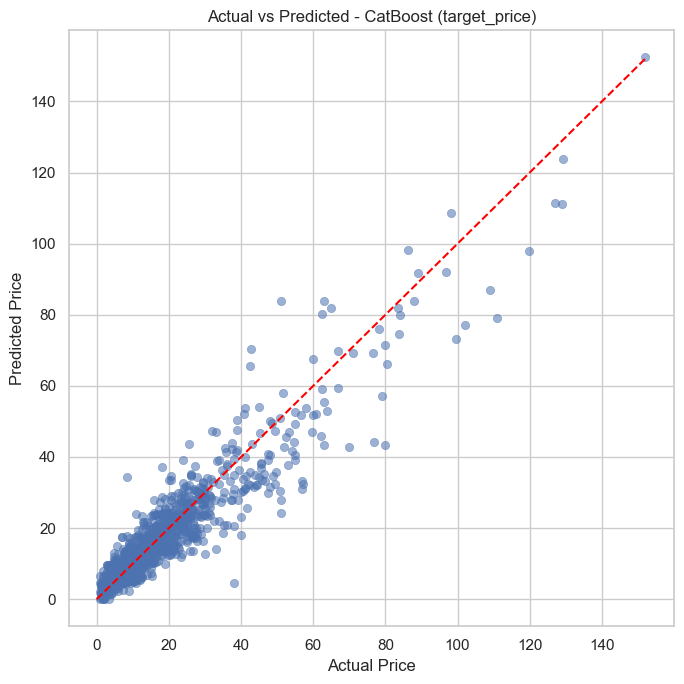

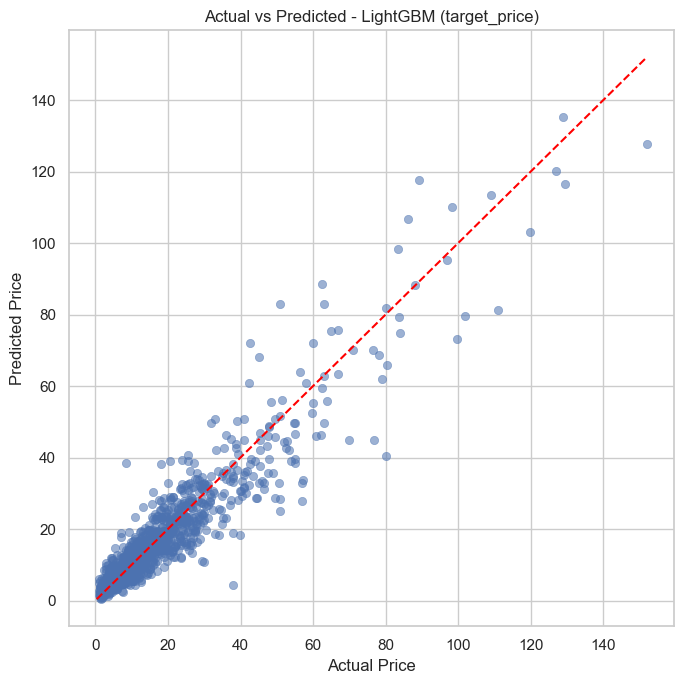

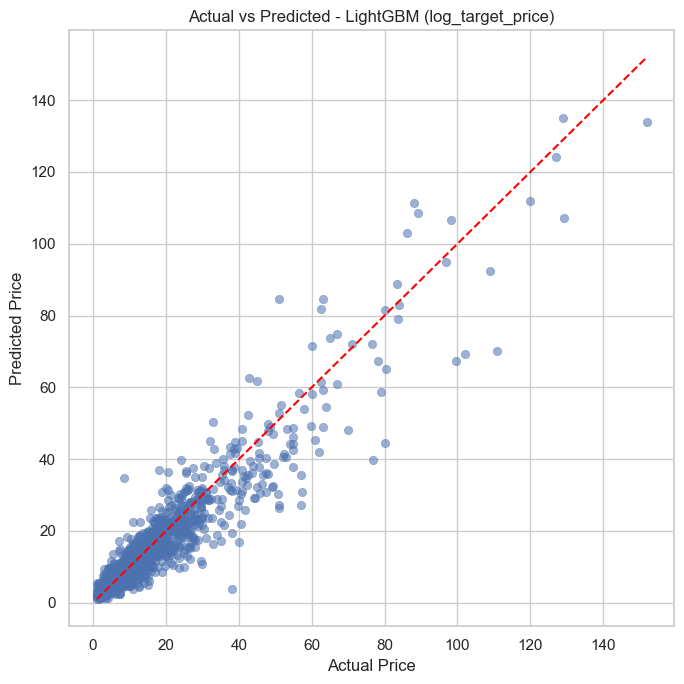

In [16]:
top_3_models = metrics_df.sort_values('rmse').head(3)[['model_name', 'target_used', 'rmse', 'mae', 'r2']]
display(top_3_models)

for _, row in top_3_models.iterrows():
    pred_col = f"pred_{safe_filename(row['model_name'], row['target_used'])}"
    plot_actual_vs_predicted(
        y_true=y_price_test,
        y_pred=predictions_df[pred_col].values,
        model_name=row['model_name'],
        target_used=row['target_used'],
    )

## Actual vs Predicted Analysis

Các biểu đồ `Actual vs Predicted` so sánh giá thật và giá dự đoán của các mô hình tốt nhất. Đường gạch đỏ biểu diễn đường dự đoán lý tưởng, tức là `predicted price = actual price`. Điểm dữ liệu càng nằm gần đường này thì mô hình dự đoán càng chính xác.

Vì `target_price` đã được scale về đơn vị triệu VND, cả trục `Actual Price` và `Predicted Price` đều được hiểu theo đơn vị triệu đồng.

Nhìn chung, cả ba mô hình đều học được xu hướng chính của dữ liệu. Phần lớn điểm dữ liệu tập trung quanh đường chéo, đặc biệt ở vùng giá thấp và trung bình. Điều này cho thấy các mô hình dự đoán tương đối tốt đối với nhóm laptop phổ biến trong tập test.

Tuy nhiên, khi giá thực tế tăng lên, các điểm bắt đầu phân tán rộng hơn quanh đường lý tưởng. Đây là dấu hiệu cho thấy mô hình dự đoán kém ổn định hơn ở nhóm laptop giá cao, vốn thường có ít mẫu hơn và có cấu hình đặc biệt hơn.

### LightGBM with `log_target_price`

Biểu đồ của `LightGBM` train trên `log_target_price` cho thấy các điểm ở vùng giá thấp và trung bình bám khá sát đường chéo. Điều này cho thấy log-transform giúp mô hình học tốt xu hướng tương đối của giá, đặc biệt ở các phân khúc phổ biến.

Ở vùng giá cao, mô hình bắt đầu xuất hiện sai số lớn hơn. Một số mẫu có giá thực tế cao bị dự đoán thấp hơn đáng kể, trong khi một số mẫu khác lại bị dự đoán cao hơn giá thật. Đây là pattern thường gặp khi dùng log target, vì log-transform có xu hướng làm giảm ảnh hưởng của các giá trị giá rất cao trong quá trình training.

Nhìn chung, `LightGBM` với `log_target_price` là một mô hình ổn định, đặc biệt nếu mục tiêu là giảm sai số trung bình cho phần lớn mẫu.

### LightGBM with `target_price`

Biểu đồ của `LightGBM` train trực tiếp trên `target_price` cũng cho thấy mô hình học được quan hệ giữa feature và giá khá tốt. Các điểm ở vùng giá thấp và trung bình vẫn tập trung gần đường lý tưởng.

So với bản `log_target_price`, bản train trực tiếp trên `target_price` có xu hướng phản ứng mạnh hơn với các mẫu giá cao, vì mô hình tối ưu trực tiếp trên thang giá thật. Tuy nhiên, ở vùng giá cao vẫn có một số điểm bị underestimate rõ rệt, tức là giá dự đoán thấp hơn nhiều so với giá thực tế.

Điều này cho thấy `LightGBM` vẫn gặp khó khăn với các laptop cao cấp, workstation, gaming cao cấp hoặc các cấu hình hiếm mà dữ liệu training có thể chưa đại diện đủ tốt.

### CatBoost with `target_price`

Biểu đồ của `CatBoost` train trực tiếp trên `target_price` cho thấy phân bố điểm khá sát đường lý tưởng, đặc biệt ở vùng giá thấp đến trung bình. Đây là vùng có mật độ dữ liệu cao nhất, nên mô hình học được pattern ổn định hơn.

Ở vùng giá cao, `CatBoost` vẫn xuất hiện một số sai số lớn, nhưng nhìn chung các điểm có xu hướng bám theo đường chéo khá tốt. Một số mẫu giá rất cao vẫn được dự đoán tương đối sát, cho thấy mô hình có khả năng học tốt hơn các quan hệ phi tuyến giữa đặc trưng laptop và giá bán.

Nhìn tổng thể, `CatBoost` với `target_price` là mô hình cân bằng tốt, đặc biệt nếu mục tiêu là tối ưu RMSE và R² trên thang giá thật.

### Error Pattern

Các điểm nằm phía trên đường đỏ là những mẫu bị mô hình dự đoán cao hơn giá thật, tức là overprediction. Ngược lại, các điểm nằm phía dưới đường đỏ là những mẫu bị dự đoán thấp hơn giá thật, tức là underprediction.

Pattern chung của cả ba biểu đồ là sai số tăng dần khi giá thực tế tăng. Vùng giá thấp và trung bình có nhiều dữ liệu hơn nên mô hình dự đoán ổn định hơn. Trong khi đó, vùng giá cao có ít mẫu hơn, cấu hình đa dạng hơn và dễ bị ảnh hưởng bởi các yếu tố khó biểu diễn đầy đủ trong feature, ví dụ như dòng máy cao cấp, GPU workstation, chất lượng màn hình, độ mới, tình trạng máy hoặc thương hiệu.

Điều này cho thấy lỗi lớn không chỉ đến từ mô hình, mà còn có thể đến từ việc feature hiện tại chưa mô tả đủ các yếu tố quyết định giá ở phân khúc cao cấp.

### Key Takeaways

Các biểu đồ xác nhận rằng `CatBoost` và `LightGBM` đều là các baseline mạnh cho bài toán dự đoán giá laptop. Cả hai mô hình đều dự đoán tốt trên phần lớn khoảng giá phổ biến.

`CatBoost` train trực tiếp trên `target_price` có vẻ là lựa chọn tốt nhất nếu ưu tiên RMSE và R², vì các điểm nhìn chung bám sát đường lý tưởng và giữ được xu hướng tốt ở nhiều khoảng giá.

`LightGBM` train trên `log_target_price` vẫn rất đáng giữ lại vì có khả năng dự đoán ổn định ở vùng giá phổ biến và thường có lợi về MAE.

Tuy nhiên, cả ba mô hình đều gặp khó khăn hơn ở vùng giá cao. Vì vậy, bước tiếp theo nên là thực hiện residual analysis, đặc biệt tập trung vào các mẫu có lỗi lớn nhất. Nên kiểm tra lỗi theo `price_range`, `brand`, `model`, `GPU type`, `CPU tier`, `condition` và `warranty` để xác định nguyên nhân sai số và cải thiện feature engineering hoặc tuning.

## 17. Generate residual and error distribution plots for top 3 models

Residual plot cho biết sai số có phân bố ngẫu nhiên hay bị lệch theo mức giá dự đoán. Error distribution plot giúp quan sát bias tổng thể: phân phối centered gần 0 là tốt, còn lệch hẳn sang một phía cho thấy model có xu hướng overestimate hoặc underestimate.

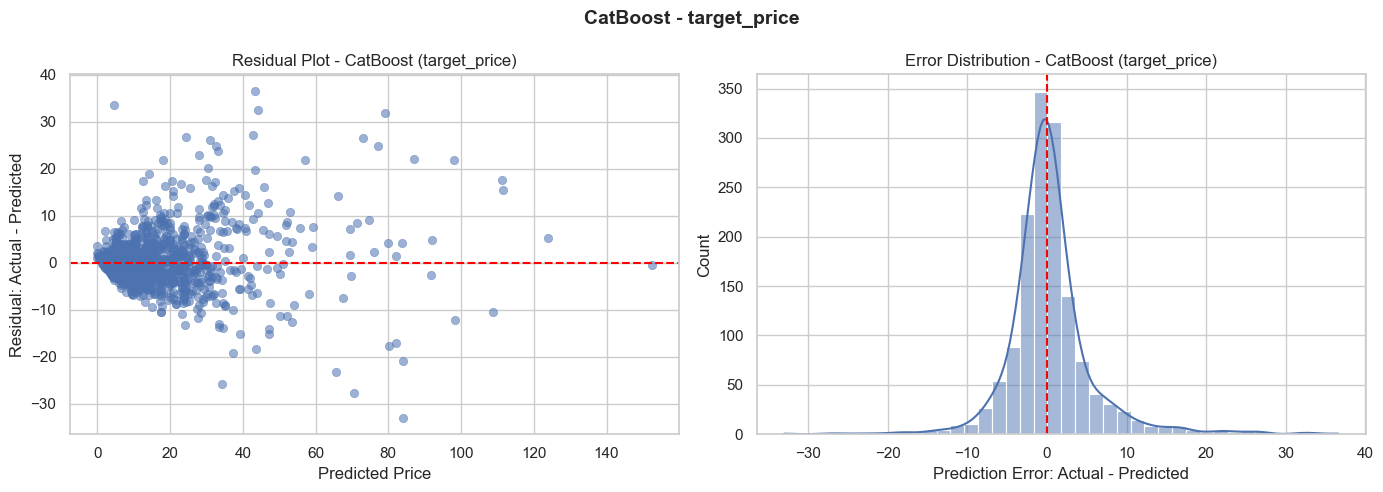

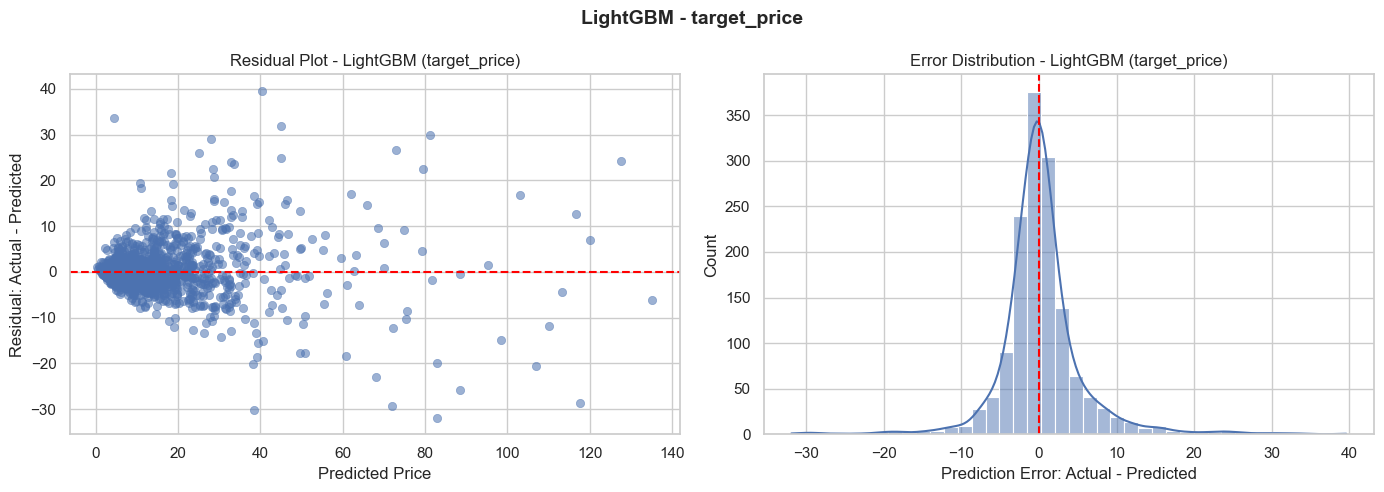

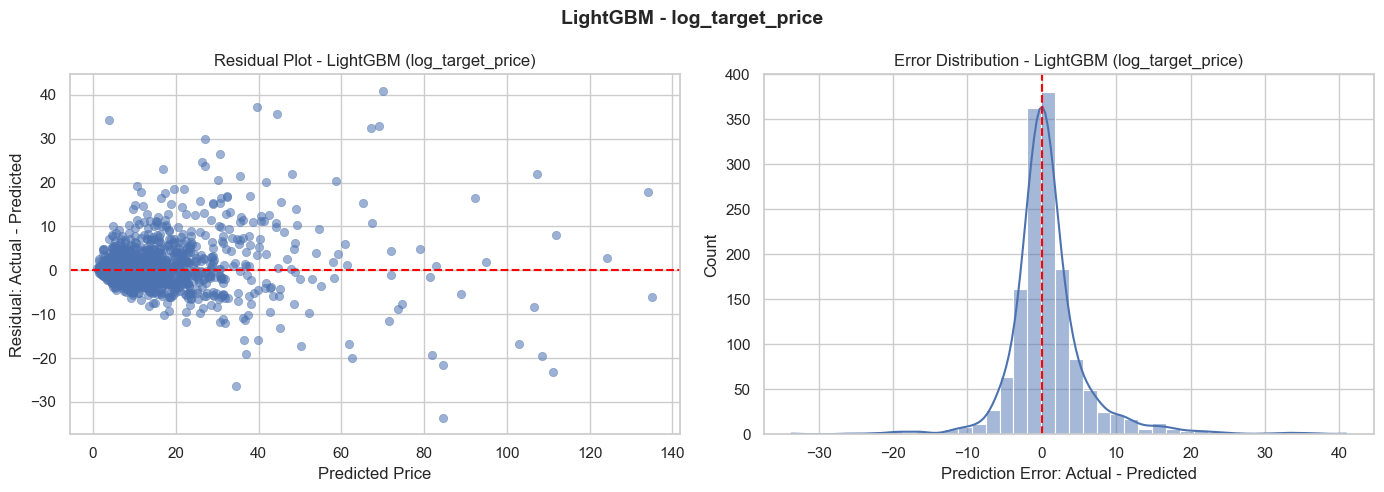

In [17]:
for _, row in top_3_models.iterrows():
    pred_col = f"pred_{safe_filename(row['model_name'], row['target_used'])}"
    y_pred_current = predictions_df[pred_col].values

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plot_residuals(
        y_true=y_price_test,
        y_pred=y_pred_current,
        model_name=row['model_name'],
        target_used=row['target_used'],
        ax=axes[0]
    )

    plot_error_distribution(
        y_true=y_price_test,
        y_pred=y_pred_current,
        model_name=row['model_name'],
        target_used=row['target_used'],
        ax=axes[1]
    )

    fig.suptitle(
        f"{row['model_name']} - {row['target_used']}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

## 18. Save feature importance / coefficients

Với tree-based model, notebook lưu `feature_importances_`; với linear model, notebook lưu coefficient table. Cột `abs_importance` hỗ trợ sắp xếp độ ảnh hưởng tuyệt đối, nhưng khi diễn giải linear coefficient vẫn nên chú ý dấu âm/dương của cột `importance`.

In [18]:
feature_importance_frames = []

for model_key, fitted_model in trained_models.items():
    model_name, target_used = model_key.rsplit('_', 1)
    importance_df = extract_feature_importance(fitted_model, model_name, feature_names)

    if importance_df is None:
        print(f'No feature importance or coefficients available for {model_key}.')
        continue

    importance_df['target_used'] = target_used
    output_columns = ['feature', 'importance', 'model_name', 'target_used', 'importance_type', 'abs_importance']
    importance_df = importance_df[output_columns]

    output_path = FEATURE_IMPORTANCE_DIR / f'{safe_filename(model_name, target_used)}_feature_importance.csv'
    importance_df.to_csv(output_path, index=False)
    feature_importance_frames.append(importance_df)
    print(f'Saved: {output_path.name}')

if feature_importance_frames:
    all_feature_importance_df = pd.concat(feature_importance_frames, ignore_index=True)
    all_feature_importance_path = FEATURE_IMPORTANCE_DIR / 'all_feature_importance.csv'
    all_feature_importance_df.to_csv(all_feature_importance_path, index=False)
    display(all_feature_importance_df.head(20))
else:
    all_feature_importance_df = pd.DataFrame()

Saved: LinearRegression_target_price_feature_importance.csv
Saved: LinearRegression_log_target_price_feature_importance.csv
Saved: Ridge_target_price_feature_importance.csv
Saved: Ridge_log_target_price_feature_importance.csv
Saved: Lasso_target_price_feature_importance.csv
Saved: Lasso_log_target_price_feature_importance.csv
Saved: ElasticNet_target_price_feature_importance.csv
Saved: ElasticNet_log_target_price_feature_importance.csv
Saved: RandomForest_target_price_feature_importance.csv
Saved: RandomForest_log_target_price_feature_importance.csv
Saved: ExtraTrees_target_price_feature_importance.csv
Saved: ExtraTrees_log_target_price_feature_importance.csv
Saved: LightGBM_target_price_feature_importance.csv
Saved: LightGBM_log_target_price_feature_importance.csv
Saved: CatBoost_target_price_feature_importance.csv
Saved: CatBoost_log_target_price_feature_importance.csv


,feature,importance,model_name,target_used,importance_type,abs_importance
0,model_Other,"-33,035,707,337,253.0156",Linear Regression_target,price,coefficient,"33,035,707,337,253.0156"
1,brand_Other,"29,386,902,384,745.2031",Linear Regression_target,price,coefficient,"29,386,902,384,745.2031"
2,no_info_model,"27,162,430,656,232.8984",Linear Regression_target,price,coefficient,"27,162,430,656,232.8984"
3,no_info_brand,"-21,717,150,220,862.4141",Linear Regression_target,price,coefficient,"21,717,150,220,862.4141"
4,brand_Dell,"16,970,554,075,070.0781",Linear Regression_target,price,coefficient,"16,970,554,075,070.0781"
5,gpu_type_Missing_Info,"15,950,199,166,624.6387",Linear Regression_target,price,coefficient,"15,950,199,166,624.6387"
6,no_info_gpu,"-15,799,407,609,468.6699",Linear Regression_target,price,coefficient,"15,799,407,609,468.6699"
7,no_info_cpu_brand,"-15,795,496,773,649.7461",Linear Regression_target,price,coefficient,"15,795,496,773,649.7461"
8,brand_Lenovo,"13,338,605,432,327.6133",Linear Regression_target,price,coefficient,"13,338,605,432,327.6133"
9,brand_Apple,"13,176,056,798,706.7148",Linear Regression_target,price,coefficient,"13,176,056,798,706.7148"


## 19. Summary of best models

Phần cuối notebook tổng hợp top model theo RMSE và MAE, so sánh `price` với `logprice` trong từng thuật toán, rồi in kết luận tự động. Kết luận có kiểm tra khoảng cách giữa các model top đầu; nếu chênh lệch nhỏ, notebook sẽ ghi rõ rằng kết quả nên được xem là sát nhau thay vì khẳng định tuyệt đối.

In [19]:
top_by_rmse = metrics_df.sort_values('rmse').head(10).reset_index(drop=True)
top_by_mae = metrics_df.sort_values('mae').head(10).reset_index(drop=True)

display(top_by_rmse)
display(top_by_mae)

# Compare price vs logprice target for each model.
target_comparison_rows = []
for model_name, group in metrics_df.groupby('model_name'):
    pivot = group.set_index('target_used')
    if {'target_price', 'log_target_price'}.issubset(pivot.index):
        price_rmse = pivot.loc['target_price', 'rmse']
        log_rmse = pivot.loc['log_target_price', 'rmse']
        price_mae = pivot.loc['target_price', 'mae']
        log_mae = pivot.loc['log_target_price', 'mae']
        target_comparison_rows.append(
            {
                'model_name': model_name,
                'price_rmse': price_rmse,
                'logprice_rmse': log_rmse,
                'rmse_winner': 'log_target_price' if log_rmse < price_rmse else 'target_price',
                'rmse_pct_diff_log_vs_price': (log_rmse - price_rmse) / price_rmse,
                'price_mae': price_mae,
                'logprice_mae': log_mae,
                'mae_winner': 'log_target_price' if log_mae < price_mae else 'target_price',
                'mae_pct_diff_log_vs_price': (log_mae - price_mae) / price_mae,
            }
        )

target_comparison_df = pd.DataFrame(target_comparison_rows).sort_values('model_name')
display(target_comparison_df)

best_rmse_row = metrics_df.loc[metrics_df['rmse'].idxmin()]
best_mae_row = metrics_df.loc[metrics_df['mae'].idxmin()]

target_summary = metrics_df.groupby('target_used')[['rmse', 'mae', 'r2']].mean().sort_values('rmse')
best_target_overall = target_summary.index[0]

rmse_gap = (
    metrics_df.sort_values('rmse').iloc[1]['rmse'] - best_rmse_row['rmse']
) / best_rmse_row['rmse'] if len(metrics_df) > 1 else np.nan

mae_gap = (
    metrics_df.sort_values('mae').iloc[1]['mae'] - best_mae_row['mae']
) / best_mae_row['mae'] if len(metrics_df) > 1 else np.nan

print('Automatic conclusion')
print('--------------------')
print(
    f"Best model by RMSE: {best_rmse_row['model_name']} trained on {best_rmse_row['target_used']} "
    f"with RMSE={best_rmse_row['rmse']:,.4f}, MAE={best_rmse_row['mae']:,.4f}, R2={best_rmse_row['r2']:,.4f}."
)
print(
    f"Best model by MAE : {best_mae_row['model_name']} trained on {best_mae_row['target_used']} "
    f"with MAE={best_mae_row['mae']:,.4f}, RMSE={best_mae_row['rmse']:,.4f}, R2={best_mae_row['r2']:,.4f}."
)
print(f"Best target overall by average RMSE across models: {best_target_overall}.")

if not np.isnan(rmse_gap) and rmse_gap < 0.02:
    print('RMSE difference between the top two variants is below 2%, so the winner should be treated as a close result.')
if not np.isnan(mae_gap) and mae_gap < 0.02:
    print('MAE difference between the top two variants is below 2%, so the winner should be treated as a close result.')

if best_target_overall == 'log_target_price':
    print('Recommendation: logprice is currently preferable on average, but confirm with residual plots and business tolerance for large-price errors.')
else:
    print('Recommendation: direct price modeling is currently preferable on average, but confirm with residual plots and segment-level errors.')

,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,CatBoost,gradient_boosting,target_price,target_price,3.3709,5.4827,0.8870,0.3001,2.0150,36.6205,2.7868,0.0073
1,LightGBM,gradient_boosting,target_price,target_price,3.2904,5.4981,0.8864,0.2817,1.8933,39.6096,2.3375,0.0160
2,LightGBM,gradient_boosting,log_target_price,target_price,3.2535,5.5300,0.8850,0.2627,1.8255,40.9106,2.6372,0.0149
3,Random Forest,tree_ensemble,target_price,target_price,3.4085,5.6870,0.8784,0.3021,1.9347,46.8513,2.7782,0.1352
4,CatBoost,gradient_boosting,log_target_price,target_price,3.3370,5.7407,0.8761,0.2621,1.8086,43.0101,2.1606,0.0040
5,Random Forest,tree_ensemble,log_target_price,target_price,3.4134,5.8456,0.8715,0.2830,1.8778,49.3828,2.4520,0.1441
6,Extra Trees,tree_ensemble,target_price,target_price,3.5442,5.9386,0.8674,0.3095,2.0429,61.2973,2.7481,0.1453
7,Extra Trees,tree_ensemble,log_target_price,target_price,3.5166,6.0317,0.8632,0.2936,1.9810,62.7549,2.7023,0.1672
8,Linear Regression,linear,log_target_price,target_price,4.0736,6.9260,0.8197,0.3191,2.1951,48.6459,1.0183,0.0226
9,Lasso,linear,log_target_price,target_price,4.0807,6.9425,0.8188,0.3196,2.1852,50.2717,1.2141,0.0133


,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,LightGBM,gradient_boosting,log_target_price,target_price,3.2535,5.5300,0.8850,0.2627,1.8255,40.9106,2.6372,0.0149
1,LightGBM,gradient_boosting,target_price,target_price,3.2904,5.4981,0.8864,0.2817,1.8933,39.6096,2.3375,0.0160
2,CatBoost,gradient_boosting,log_target_price,target_price,3.3370,5.7407,0.8761,0.2621,1.8086,43.0101,2.1606,0.0040
3,CatBoost,gradient_boosting,target_price,target_price,3.3709,5.4827,0.8870,0.3001,2.0150,36.6205,2.7868,0.0073
4,Random Forest,tree_ensemble,target_price,target_price,3.4085,5.6870,0.8784,0.3021,1.9347,46.8513,2.7782,0.1352
5,Random Forest,tree_ensemble,log_target_price,target_price,3.4134,5.8456,0.8715,0.2830,1.8778,49.3828,2.4520,0.1441
6,Extra Trees,tree_ensemble,log_target_price,target_price,3.5166,6.0317,0.8632,0.2936,1.9810,62.7549,2.7023,0.1672
7,Extra Trees,tree_ensemble,target_price,target_price,3.5442,5.9386,0.8674,0.3095,2.0429,61.2973,2.7481,0.1453
8,Linear Regression,linear,log_target_price,target_price,4.0736,6.9260,0.8197,0.3191,2.1951,48.6459,1.0183,0.0226
9,ElasticNet,linear,log_target_price,target_price,4.0807,6.9437,0.8188,0.3194,2.1634,50.0881,0.5905,0.0032


,model_name,price_rmse,logprice_rmse,rmse_winner,rmse_pct_diff_log_vs_price,price_mae,logprice_mae,mae_winner,mae_pct_diff_log_vs_price
0,CatBoost,5.4827,5.7407,target_price,0.0471,3.3709,3.3370,log_target_price,-0.0101
1,ElasticNet,7.9246,6.9437,log_target_price,-0.1238,4.7187,4.0807,log_target_price,-0.1352
2,Extra Trees,5.9386,6.0317,target_price,0.0157,3.5442,3.5166,log_target_price,-0.0078
3,Lasso,7.9250,6.9425,log_target_price,-0.1240,4.7197,4.0807,log_target_price,-0.1354
4,LightGBM,5.4981,5.5300,target_price,0.0058,3.2904,3.2535,log_target_price,-0.0112
5,Linear Regression,7.9334,6.9260,log_target_price,-0.1270,4.7241,4.0736,log_target_price,-0.1377
6,Random Forest,5.6870,5.8456,target_price,0.0279,3.4085,3.4134,target_price,0.0014
7,Ridge,7.9249,6.9602,log_target_price,-0.1217,4.7201,4.0868,log_target_price,-0.1342


Automatic conclusion
--------------------
Best model by RMSE: CatBoost trained on target_price with RMSE=5.4827, MAE=3.3709, R2=0.8870.
Best model by MAE : LightGBM trained on log_target_price with MAE=3.2535, RMSE=5.5300, R2=0.8850.
Best target overall by average RMSE across models: log_target_price.
RMSE difference between the top two variants is below 2%, so the winner should be treated as a close result.
MAE difference between the top two variants is below 2%, so the winner should be treated as a close result.
Recommendation: logprice is currently preferable on average, but confirm with residual plots and business tolerance for large-price errors.
